In [1]:
!pip install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00


In [3]:
import random
import numpy as np
import torch

def set_seed(seed_val=42):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

set_seed(42)

In [4]:
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [10]:
data_files = {"train": "https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/all.jsonl"}
dataset = load_dataset("json", data_files=data_files)

df = pd.DataFrame(dataset["train"])

humans = pd.DataFrame()
humans["text"] = df["human_answers"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
humans["label"] = 0

ais = pd.DataFrame()
ais["text"] = df["chatgpt_answers"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
ais["label"] = 1

full_df = pd.concat([humans, ais])

full_df = full_df[full_df["text"].str.len() > 10]
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)
df_final = full_df.head(6000)

df_final.head(100).to_csv("sample_dataset.csv", index=False)

In [11]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)
hf_dataset = Dataset.from_pandas(df_final)
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

In [12]:
small_train_dataset = tokenized_datasets.select(range(4800))
small_eval_dataset = tokenized_datasets.select(range(4800, 6000))

In [13]:
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
training_args = TrainingArguments(
    output_dir="roberta_trainer",
    eval_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.091200,0.058286,0.990833,0.990443,0.981067,1.000000
2,0.015500,0.145987,0.981667,0.981067,0.962838,1.000000
3,0.002900,0.031359,0.995000,0.994764,0.989583,1.000000


TrainOutput(global_step=1800, training_loss=0.030941605203681524, metrics={'train_runtime': 1483.2724, 'train_samples_per_second': 9.708, 'train_steps_per_second': 1.214, 'total_flos': 3788799197184000.0, 'train_loss': 0.030941605203681524, 'epoch': 3.0})

In [17]:
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.03135880082845688, 'eval_accuracy': 0.995, 'eval_f1': 0.9947643979057592, 'eval_precision': 0.9895833333333334, 'eval_recall': 1.0, 'eval_runtime': 31.8805, 'eval_samples_per_second': 37.641, 'eval_steps_per_second': 4.705, 'epoch': 3.0}


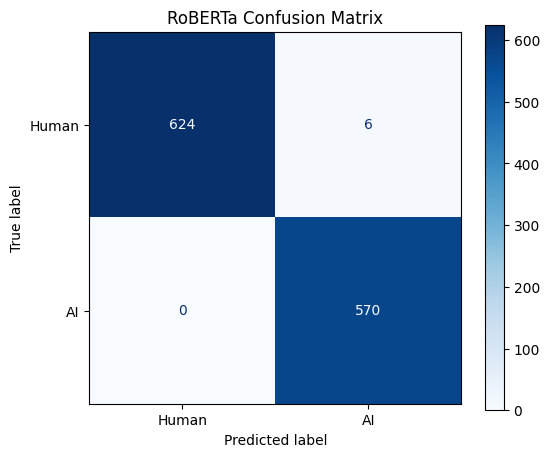

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

outputs = trainer.predict(small_eval_dataset)
y_pred = outputs.predictions.argmax(-1)
y_true = outputs.label_ids

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Human", "AI"], ax=ax, cmap="Blues")
plt.title("RoBERTa Confusion Matrix")
plt.show()

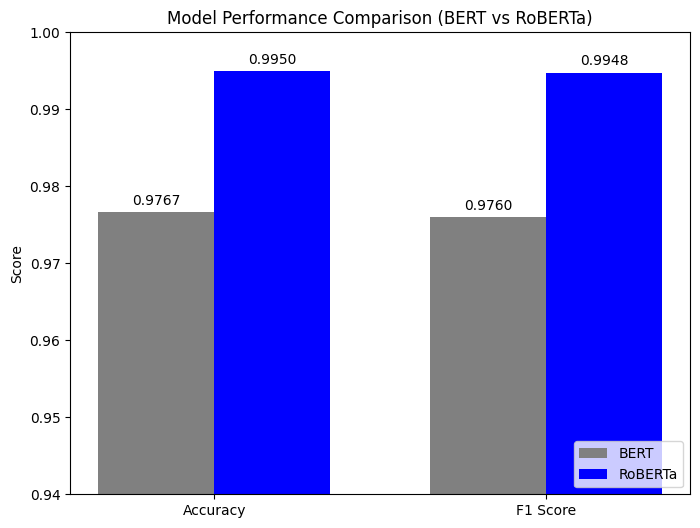

In [19]:
import numpy as np
import matplotlib.pyplot as plt

bert_accuracy = 0.9767
bert_f1 = 0.9760

roberta_accuracy = metrics["eval_accuracy"]
roberta_f1 = metrics["eval_f1"]

labels = ['Accuracy', 'F1 Score']
bert_scores = [bert_accuracy, bert_f1]
roberta_scores = [roberta_accuracy, roberta_f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, bert_scores, width, label='BERT', color='gray')
rects2 = ax.bar(x + width/2, roberta_scores, width, label='RoBERTa', color='blue')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (BERT vs RoBERTa)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='lower right')
ax.set_ylim(0.94, 1.00)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()